# Peramalan Harga Saham INDF - Model Tunggal BiLSTM
**Model tunggal BiLSTM (tanpa CNN) untuk perbandingan dengan Hybrid CNN-BiLSTM**

Grid parameter:
- n_units         : [16, 32, 64]
- n_bilstm_layers : [1, 2]
- dropout_rate    : [0.1, 0.2, 0.3]
- batch_size      : [16, 32, 64]
- Total: 3 x 2 x 3 x 3 = 54 kombinasi x 3 skenario = 162 run


## CELL 1 — Pra-Pemrosesan Data

## CELL 3 — Load Data & Fungsi Windowing

In [1]:
import pandas as pd
import numpy as np
import tensorflow as tf
from sklearn.preprocessing import MinMaxScaler

tf.random.set_seed(42)
np.random.seed(42)

# Load data bersih
df = pd.read_csv('INDF_Cleaned.csv', parse_dates=['Date'], index_col='Date')
data_full = df[['Close']].values   # Gunakan harga asli (Rupiah)

# Parameter tetap
WINDOW_SIZE = 30

def create_window_dataset(dataset, lookback):
    """Membuat pasangan (X, y) dari data time series dengan sliding window."""
    X, y = [], []
    for i in range(lookback, len(dataset)):
        X.append(dataset[i-lookback:i])
        y.append(dataset[i])
    return np.array(X), np.array(y)

# ==========================================
# INTI: FUNGSI PEMBAGI SKENARIO
# ==========================================
def jalankan_skenario(ratio_train, ratio_val, ratio_test):
    """
    Membagi data, normalisasi, lalu windowing dari data gabungan
    agar konteks antar segmen (train→val→test) tetap terjaga.

    Alur:
      1. Split data mentah (Close) → train / val / test
      2. Fit scaler HANYA pada train → transform val & test
      3. Gabungkan kembali → window dari full scaled
      4. Potong window hasil menjadi 3 bagian sesuai proporsi
    """
    label = f"{int(ratio_train*100)}-{int(ratio_val*100)}-{int(ratio_test*100)}"
    print(f"\n>>> MEMPERSIAPKAN SKENARIO {label} ...")

    n       = len(data_full)
    n_train = int(ratio_train * n)
    n_val   = int(ratio_val   * n)
    n_test  = n - n_train - n_val

    # 1. Split data mentah
    train_raw = data_full[:n_train]
    val_raw   = data_full[n_train : n_train + n_val]
    test_raw  = data_full[n_train + n_val :]

    # 2. Normalisasi — fit HANYA pada train (cegah data leakage)
    scaler = MinMaxScaler(feature_range=(0, 1))
    train_scaled = scaler.fit_transform(train_raw)
    val_scaled   = scaler.transform(val_raw)
    test_scaled  = scaler.transform(test_raw)

    # 3. Gabungkan untuk windowing (konteks antar segmen terjaga)
    full_scaled = np.concatenate([train_scaled, val_scaled, test_scaled])
    X_all, y_all = create_window_dataset(full_scaled, WINDOW_SIZE)

    # 4. Potong kembali sesuai proporsi
    # Jumlah window yang "dimiliki" tiap segmen:
    #   - Train menghasilkan (n_train - WINDOW_SIZE) window
    #   - Val & Test masing-masing menghasilkan n_val dan n_test window
    #     (mereka "meminjam" WINDOW_SIZE terakhir dari segmen sebelumnya sebagai konteks)
    n_train_w = n_train - WINDOW_SIZE
    n_val_w   = n_val
    # n_test_w  = n_test (sisa)

    X_train = X_all[:n_train_w]
    y_train = y_all[:n_train_w]

    X_val   = X_all[n_train_w : n_train_w + n_val_w]
    y_val   = y_all[n_train_w : n_train_w + n_val_w]

    X_test  = X_all[n_train_w + n_val_w :]
    y_test  = y_all[n_train_w + n_val_w :]

    print(f"   Total data      : {n} baris")
    print(f"   Train (mentah)  : {n_train} | Val: {n_val} | Test: {n_test}")
    print(f"   Shape X_train   : {X_train.shape}")
    print(f"   Shape X_val     : {X_val.shape}")
    print(f"   Shape X_test    : {X_test.shape}")

    return {
        'X_train': X_train, 'y_train': y_train,
        'X_val'  : X_val,   'y_val'  : y_val,
        'X_test' : X_test,  'y_test' : y_test,
        'scaler' : scaler
    }

# ==========================================
# EKSEKUSI 3 SKENARIO
# ==========================================
# List skenario: (Train, Val, Test)
skenario_list = [
    (0.80, 0.10, 0.10),
    (0.70, 0.15, 0.15),
    (0.60, 0.20, 0.20)
]

# Dictionary untuk menyimpan semua data siap pakai
datasets = {}

for r_train, r_val, r_test in skenario_list:
    nama = f"{int(r_train*100)}-{int(r_val*100)}-{int(r_test*100)}"
    datasets[nama] = jalankan_skenario(r_train, r_val, r_test)

print("\n✅ Semua skenario siap! Akses: datasets['80-10-10']['X_train']")


>>> MEMPERSIAPKAN SKENARIO 80-10-10 ...
   Total data      : 2609 baris
   Train (mentah)  : 2087 | Val: 260 | Test: 262
   Shape X_train   : (2057, 30, 1)
   Shape X_val     : (260, 30, 1)
   Shape X_test    : (262, 30, 1)

>>> MEMPERSIAPKAN SKENARIO 70-15-15 ...
   Total data      : 2609 baris
   Train (mentah)  : 1826 | Val: 391 | Test: 392
   Shape X_train   : (1796, 30, 1)
   Shape X_val     : (391, 30, 1)
   Shape X_test    : (392, 30, 1)

>>> MEMPERSIAPKAN SKENARIO 60-20-20 ...
   Total data      : 2609 baris
   Train (mentah)  : 1565 | Val: 521 | Test: 523
   Shape X_train   : (1535, 30, 1)
   Shape X_val     : (521, 30, 1)
   Shape X_test    : (523, 30, 1)

✅ Semua skenario siap! Akses: datasets['80-10-10']['X_train']


## CELL 5 - Definisi Arsitektur Model BiLSTM (Tunggal)


In [2]:
import time
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Bidirectional, LSTM,
                                     Dense, Dropout)
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

tf.random.set_seed(42)
np.random.seed(42)

def bangun_model(window_size, n_units, n_bilstm_layers, dropout_rate):
    """
    Model BiLSTM tunggal (tanpa CNN).
    Arsitektur: BiLSTM (1 atau 2 layer) -> Dropout -> Dense(1)
    """
    model = Sequential(name=f"BiLSTM_u{n_units}_l{n_bilstm_layers}")

    if n_bilstm_layers == 1:
        model.add(Bidirectional(LSTM(n_units, return_sequences=False),
                                input_shape=(window_size, 1)))
        model.add(Dropout(dropout_rate))
    else:
        model.add(Bidirectional(LSTM(n_units, return_sequences=True),
                                input_shape=(window_size, 1)))
        model.add(Dropout(dropout_rate))
        model.add(Bidirectional(LSTM(n_units // 2, return_sequences=False)))
        model.add(Dropout(dropout_rate))

    model.add(Dense(1))
    model.compile(optimizer='adam', loss='mse')
    return model

def hitung_metrik(y_true_scaled, y_pred_scaled, scaler):
    y_true = scaler.inverse_transform(y_true_scaled.reshape(-1, 1)).flatten()
    y_pred = scaler.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    r2   = r2_score(y_true, y_pred)
    return mae, rmse, mape, r2

print("Fungsi model BiLSTM tunggal siap digunakan.")


Fungsi model BiLSTM tunggal siap digunakan.


## CELL 6 - Hyperparameter Tuning BiLSTM (Grid Search)

Grid: n_units [16,32,64] x n_bilstm_layers [1,2] x dropout [0.1,0.2,0.3] x batch_size [16,32,64]
= 54 kombinasi x 3 skenario = 162 run


In [3]:
from itertools import product
import os

os.makedirs('models', exist_ok=True)

param_grid = {
    'n_units'         : [16, 32, 64],
    'n_bilstm_layers' : [1, 2],
    'dropout_rate'    : [0.1, 0.2, 0.3],
    'batch_size'      : [16, 32, 64],
}

EPOCHS   = 30
PATIENCE = 10
skenario_list = ['80-10-10', '70-15-15', '60-20-20']

kombinasi = list(product(
    param_grid['n_units'],
    param_grid['n_bilstm_layers'],
    param_grid['dropout_rate'],
    param_grid['batch_size'],
))

total_kombi    = len(kombinasi)
total_skenario = len(skenario_list)
total_run      = total_kombi * total_skenario

print("=" * 70)
print("  HYPERPARAMETER TUNING BiLSTM (TUNGGAL)")
print(f"  {total_kombi} kombinasi x {total_skenario} skenario = {total_run} total run")
print("=" * 70)

hasil_tuning = []

for nama_skenario in skenario_list:
    data    = datasets[nama_skenario]
    X_train = data['X_train']
    y_train = data['y_train']
    X_val   = data['X_val']
    y_val   = data['y_val']
    X_test  = data['X_test']
    y_test  = data['y_test']
    scaler  = data['scaler']

    print(f"\n>>> SKENARIO {nama_skenario}")
    print("-" * 70)

    import tensorflow as tf

    for idx, (n_units, n_layers, dropout, batch_size) in enumerate(kombinasi, 1):
        nama = f"u{n_units}_l{n_layers}_d{int(dropout*10)}_b{batch_size}"
        print(f"  [{idx:03d}/{total_kombi}] {nama} ...", end=' ')

        model = bangun_model(
            window_size     = WINDOW_SIZE,
            n_units         = n_units,
            n_bilstm_layers = n_layers,
            dropout_rate    = dropout
        )

        early_stop = EarlyStopping(
            monitor='val_loss', patience=PATIENCE,
            restore_best_weights=True, verbose=0
        )

        waktu_mulai = time.time()
        history = model.fit(
            X_train, y_train,
            epochs          = EPOCHS,
            batch_size      = batch_size,
            validation_data = (X_val, y_val),
            callbacks       = [early_stop],
            verbose         = 0
        )
        durasi_detik   = time.time() - waktu_mulai
        epoch_berhenti = len(history.history['loss'])

        y_pred = model.predict(X_test, verbose=0)
        mae, rmse, mape, r2 = hitung_metrik(y_test, y_pred, scaler)

        hasil_tuning.append({
            'Nama'          : nama,
            'Skenario'      : nama_skenario,
            'Unit BiLSTM'   : n_units,
            'Layer BiLSTM'  : n_layers,
            'Dropout'       : dropout,
            'Batch Size'    : batch_size,
            'Epoch Berhenti': epoch_berhenti,
            'Waktu (detik)' : round(durasi_detik, 2),
            'MAE'           : round(mae, 4),
            'RMSE'          : round(rmse, 4),
            'MAPE (%)'      : round(mape, 4),
            'R2'             : round(r2, 4),
        })

        print(f"Epoch: {epoch_berhenti} | Waktu: {durasi_detik:.2f} dtk | MAPE: {mape:.4f}%")

df_tuning = pd.DataFrame(hasil_tuning)
df_tuning.to_csv('hasil_tuning_BiLSTM.csv', index=False)

print("\n" + "=" * 70)
print("  TOP 1 KONFIGURASI PER SKENARIO - BiLSTM")
print("=" * 70)
top1_per_skenario = {}
for nama_skenario in skenario_list:
    subset = df_tuning[df_tuning['Skenario'] == nama_skenario]
    top1   = subset.loc[subset['MAPE (%)'].idxmin()]
    top1_per_skenario[nama_skenario] = top1
    print(f"  {nama_skenario} -> {top1['Nama']} | "
          f"MAE: {top1['MAE']} | RMSE: {top1['RMSE']} | MAPE: {top1['MAPE (%)']}%")

best_overall = df_tuning.loc[df_tuning['MAPE (%)'].idxmin()]
print("\n" + "=" * 70)
print("  KONFIGURASI TERBAIK KESELURUHAN - BiLSTM")
print("=" * 70)
print(f"  Nama         : {best_overall['Nama']}")
print(f"  Skenario     : {best_overall['Skenario']}")
print(f"  Unit BiLSTM  : {int(best_overall['Unit BiLSTM'])}")
print(f"  Layer BiLSTM : {int(best_overall['Layer BiLSTM'])}")
print(f"  Dropout      : {best_overall['Dropout']}")
print(f"  Batch Size   : {int(best_overall['Batch Size'])}")
print(f"  MAE          : {best_overall['MAE']}")
print(f"  RMSE         : {best_overall['RMSE']}")
print(f"  MAPE         : {best_overall['MAPE (%)']}%")
print(f"  R2           : {best_overall['R2']}")
print("\nHasil tuning disimpan ke: 'hasil_tuning_BiLSTM.csv'")


  HYPERPARAMETER TUNING BiLSTM (TUNGGAL)
  54 kombinasi x 3 skenario = 162 total run

>>> SKENARIO 80-10-10
----------------------------------------------------------------------
  [001/54] u16_l1_d1_b16 ... 

C:\Users\user\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\rnn\bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch: 30 | Waktu: 56.68 dtk | MAPE: 2.0271%
  [002/54] u16_l1_d1_b32 ... 

C:\Users\user\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\rnn\bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch: 30 | Waktu: 35.08 dtk | MAPE: 2.3241%
  [003/54] u16_l1_d1_b64 ... 

...

Epoch: 30 | Waktu: 182.59 dtk | MAPE: 1.3925%
  [053/54] u64_l2_d3_b32 ... 

C:\Users\user\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\rnn\bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch: 30 | Waktu: 125.19 dtk | MAPE: 1.4518%
  [054/54] u64_l2_d3_b64 ... 

C:\Users\user\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\rnn\bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch: 30 | Waktu: 87.68 dtk | MAPE: 1.6314%

  TOP 1 KONFIGURASI PER SKENARIO - BiLSTM
  80-10-10 -> u64_l1_d1_b16 | MAE: 125.5015 | RMSE: 175.9345 | MAPE: 1.6316%
  70-15-15 -> u64_l1_d1_b16 | MAE: 99.9395 | RMSE: 145.2109 | MAPE: 1.3571%
  60-20-20 -> u64_l1_d1_b16 | MAE: 94.6131 | RMSE: 146.4906 | MAPE: 1.3069%

  KONFIGURASI TERBAIK KESELURUHAN - BiLSTM
  Nama         : u64_l1_d1_b16
  Skenario     : 60-20-20
  Unit BiLSTM  : 64
  Layer BiLSTM : 1
  Dropout      : 0.1
  Batch Size   : 16
  MAE          : 94.6131
  RMSE         : 146.4906
  MAPE         : 1.3069%
  R2           : 0.9605

Hasil tuning disimpan ke: 'hasil_tuning_BiLSTM.csv'


## CELL 7 — Visualisasi Trade-Off Tuning

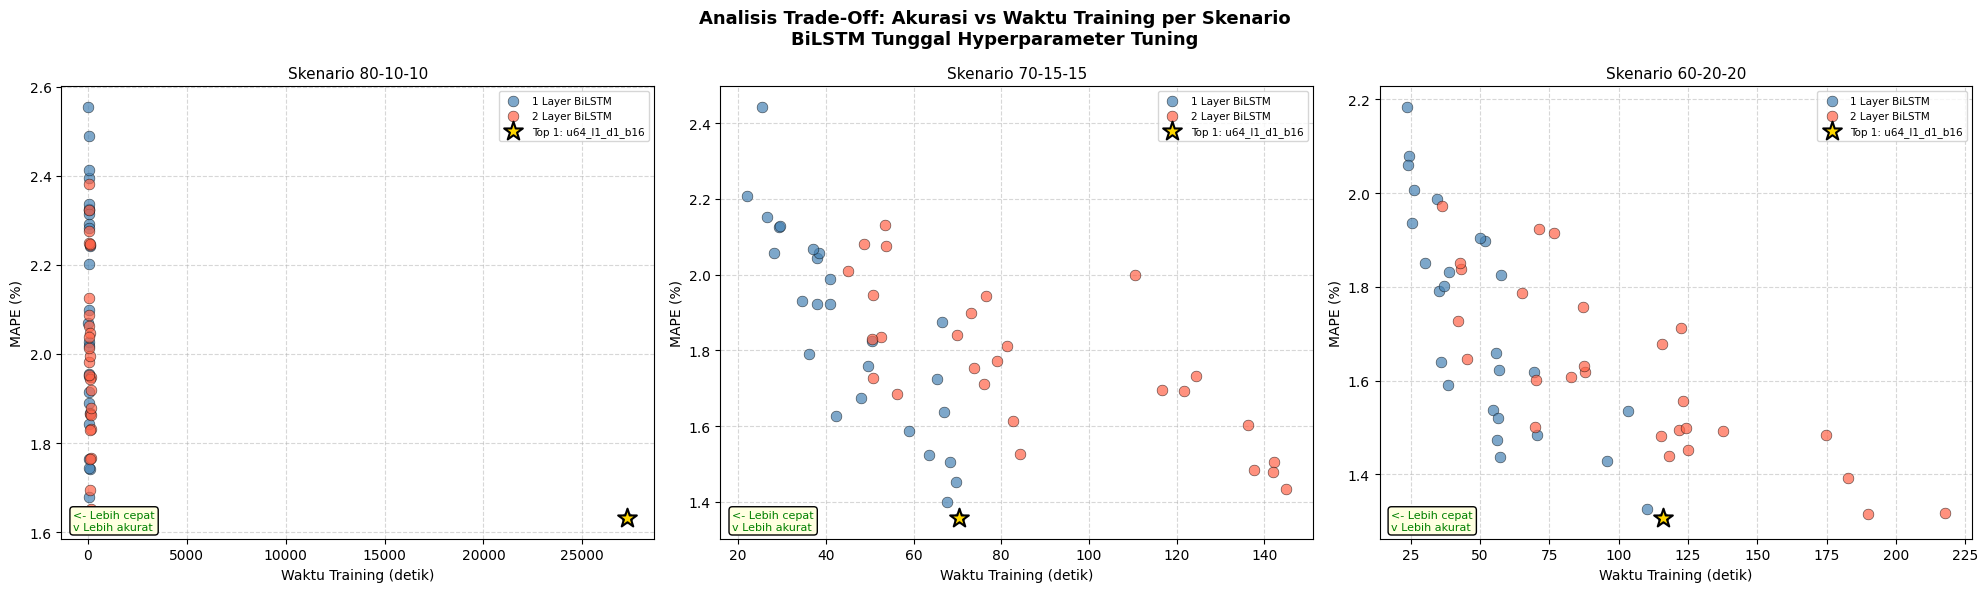

✅ Grafik trade-off disimpan ke: 'tradeoff_tuning.png'


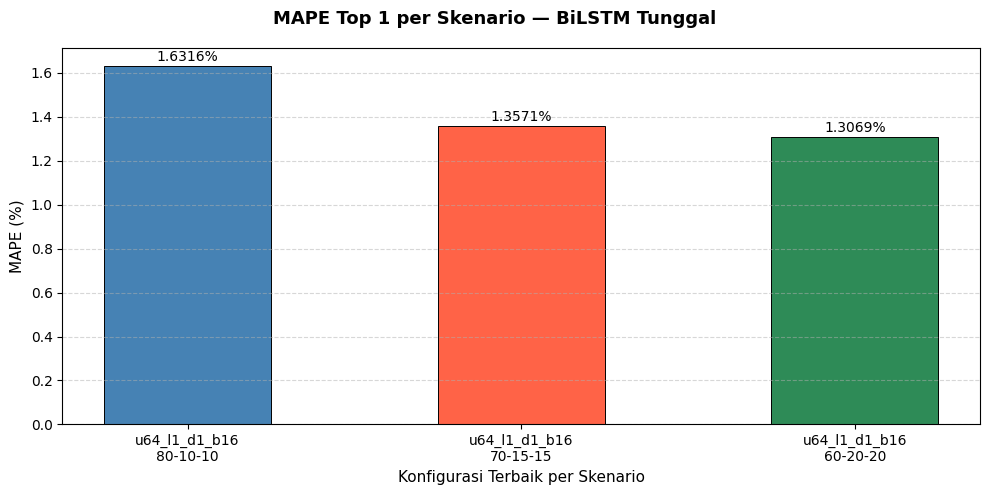

✅ Grafik top 1 per skenario disimpan ke: 'top1_per_skenario.png'


In [6]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle(
    'Analisis Trade-Off: Akurasi vs Waktu Training per Skenario\n'
    'BiLSTM Tunggal Hyperparameter Tuning',
    fontsize=13, fontweight='bold'
)

colors_layer = {1: 'steelblue', 2: 'tomato'}

for col_idx, nama_skenario in enumerate(skenario_list):
    ax     = axes[col_idx]
    subset = df_tuning[df_tuning['Skenario'] == nama_skenario]
    top1   = top1_per_skenario[nama_skenario]

    for n_layer in [1, 2]:
        s = subset[subset['Layer BiLSTM'] == n_layer]
        ax.scatter(
            s['Waktu (detik)'], s['MAPE (%)'],
            c=colors_layer[n_layer],
            label=f'{n_layer} Layer BiLSTM',
            s=60, edgecolors='black', linewidths=0.4, alpha=0.7, zorder=3
        )

    # Highlight top 1
    ax.scatter(
        [top1['Waktu (detik)']], [top1['MAPE (%)']],
        c='gold', s=200, edgecolors='black',
        linewidths=1.5, zorder=5, marker='*',
        label=f"Top 1: {top1['Nama']}"
    )

    ax.set_title(f'Skenario {nama_skenario}', fontsize=11)
    ax.set_xlabel('Waktu Training (detik)', fontsize=10)
    ax.set_ylabel('MAPE (%)', fontsize=10)
    ax.legend(fontsize=7.5)
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.annotate(
        '<- Lebih cepat\nv Lebih akurat',
        xy=(0.02, 0.02), xycoords='axes fraction',
        fontsize=8, color='green',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow')
    )

plt.tight_layout()
plt.savefig('tradeoff_tuning.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Grafik trade-off disimpan ke: 'tradeoff_tuning.png'")

# Bar chart top 1 per skenario
fig, ax = plt.subplots(figsize=(10, 5))
fig.suptitle('MAPE Top 1 per Skenario — BiLSTM Tunggal', fontsize=13, fontweight='bold')

nama_list = [top1_per_skenario[s]['Nama'] + '\n' + s for s in skenario_list]
mape_list = [top1_per_skenario[s]['MAPE (%)'] for s in skenario_list]
bars      = ax.bar(nama_list, mape_list, color=['steelblue', 'tomato', 'seagreen'],
                   edgecolor='black', linewidth=0.7, width=0.5)

for bar, val in zip(bars, mape_list):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.01,
            f'{val:.4f}%', ha='center', va='bottom', fontsize=10)

ax.set_ylabel('MAPE (%)', fontsize=11)
ax.set_xlabel('Konfigurasi Terbaik per Skenario', fontsize=11)
ax.grid(True, axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('top1_per_skenario.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Grafik top 1 per skenario disimpan ke: 'top1_per_skenario.png'")


## CELL 8 - Training Final BiLSTM: 1 Konfigurasi Terbaik x 3 Skenario


In [7]:
best_overall = df_tuning.loc[df_tuning['MAPE (%)'].idxmin()]

konfigurasi_terbaik = {
    'nama'           : best_overall['Nama'],
    'n_units'        : int(best_overall['Unit BiLSTM']),
    'n_bilstm_layers': int(best_overall['Layer BiLSTM']),
    'dropout_rate'   : float(best_overall['Dropout']),
    'batch_size'     : int(best_overall['Batch Size']),
}

skenario_final = ['80-10-10', '70-15-15', '60-20-20']
EPOCHS_FINAL   = 30
PATIENCE_FINAL = 10

hasil_final   = []
history_final = {}
model_final   = {}

print("=" * 70)
print("  TRAINING FINAL BiLSTM (TUNGGAL)")
print(f"  Konfigurasi: {konfigurasi_terbaik['nama']}")
print("=" * 70)

for nama_skenario in skenario_final:
    key  = f"{konfigurasi_terbaik['nama']}_{nama_skenario}"
    data = datasets[nama_skenario]
    print(f"\n>>> [{key}]")

    model = bangun_model(
        window_size     = WINDOW_SIZE,
        n_units         = konfigurasi_terbaik['n_units'],
        n_bilstm_layers = konfigurasi_terbaik['n_bilstm_layers'],
        dropout_rate    = konfigurasi_terbaik['dropout_rate'],
    )

    early_stop = EarlyStopping(
        monitor='val_loss', patience=PATIENCE_FINAL,
        restore_best_weights=True, verbose=0
    )
    checkpoint = ModelCheckpoint(
        filepath=f"models/{key}_BiLSTM.keras",
        monitor='val_loss', save_best_only=True, verbose=0
    )

    waktu_mulai = time.time()
    history = model.fit(
        data['X_train'], data['y_train'],
        epochs          = EPOCHS_FINAL,
        batch_size      = konfigurasi_terbaik['batch_size'],
        validation_data = (data['X_val'], data['y_val']),
        callbacks       = [early_stop, checkpoint],
        verbose         = 0
    )
    durasi_detik   = time.time() - waktu_mulai
    epoch_berhenti = len(history.history['loss'])

    y_pred = model.predict(data['X_test'], verbose=0)
    mae, rmse, mape, r2 = hitung_metrik(data['y_test'], y_pred, data['scaler'])

    hasil_final.append({
        'Konfigurasi'   : konfigurasi_terbaik['nama'],
        'Skenario'      : nama_skenario,
        'Epoch Berhenti': epoch_berhenti,
        'Waktu (detik)' : round(durasi_detik, 2),
        'MAE'           : round(mae, 4),
        'RMSE'          : round(rmse, 4),
        'MAPE (%)'      : round(mape, 4),
        'R2'            : round(r2, 4),
    })

    history_final[key] = history.history
    model_final[key]   = model

    print(f"    Epoch: {epoch_berhenti} | Waktu: {durasi_detik:.2f} dtk | "
          f"MAE: {mae:.2f} | RMSE: {rmse:.2f} | MAPE: {mape:.4f}% | R²: {r2:.4f}")

df_final_hasil = pd.DataFrame(hasil_final)
df_final_hasil.to_csv('hasil_training_final_BiLSTM.csv', index=False)

print("\n" + "=" * 70)
print("  REKAP HASIL TRAINING FINAL BiLSTM")
print("=" * 70)
print(df_final_hasil.to_string(index=False))

best_idx      = df_final_hasil['MAPE (%)'].idxmin()
best_row      = df_final_hasil.loc[best_idx]
best_skenario = best_row['Skenario']
best_key      = f"{konfigurasi_terbaik['nama']}_{best_skenario}"
best_mape     = best_row['MAPE (%)']
best_mae      = best_row['MAE']
best_rmse     = best_row['RMSE']
best_r2       = best_row['R2']
best_label    = f"BiLSTM ({konfigurasi_terbaik['nama']})"

print(f"\nModel terbaik BiLSTM: {best_key} | MAPE: {best_mape}% | R²: {best_r2:.4f}")


  TRAINING FINAL BiLSTM (TUNGGAL)
  Konfigurasi: u64_l1_d1_b16

>>> [u64_l1_d1_b16_80-10-10]


C:\Users\user\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\rnn\bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


    Epoch: 30 | Waktu: 90.59 dtk | MAE: 127.59 | RMSE: 180.40 | MAPE: 1.6586% | R²: 0.7771

>>> [u64_l1_d1_b16_70-15-15]


C:\Users\user\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\rnn\bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


    Epoch: 30 | Waktu: 74.17 dtk | MAE: 101.73 | RMSE: 149.32 | MAPE: 1.3809% | R²: 0.9582

>>> [u64_l1_d1_b16_60-20-20]


C:\Users\user\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\rnn\bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


    Epoch: 30 | Waktu: 73.12 dtk | MAE: 94.76 | RMSE: 145.58 | MAPE: 1.3076% | R²: 0.9610

  REKAP HASIL TRAINING FINAL BiLSTM
  Konfigurasi Skenario  Epoch Berhenti  Waktu (detik)      MAE     RMSE  MAPE (%)     R2
u64_l1_d1_b16 80-10-10              30          90.59 127.5868 180.4014    1.6586 0.7771
u64_l1_d1_b16 70-15-15              30          74.17 101.7269 149.3249    1.3809 0.9582
u64_l1_d1_b16 60-20-20              30          73.12  94.7558 145.5809    1.3076 0.9610

Model terbaik BiLSTM: u64_l1_d1_b16_60-20-20 | MAPE: 1.3076% | R²: 0.9610


## CELL 9 — Loss Curve (Training vs Validation)

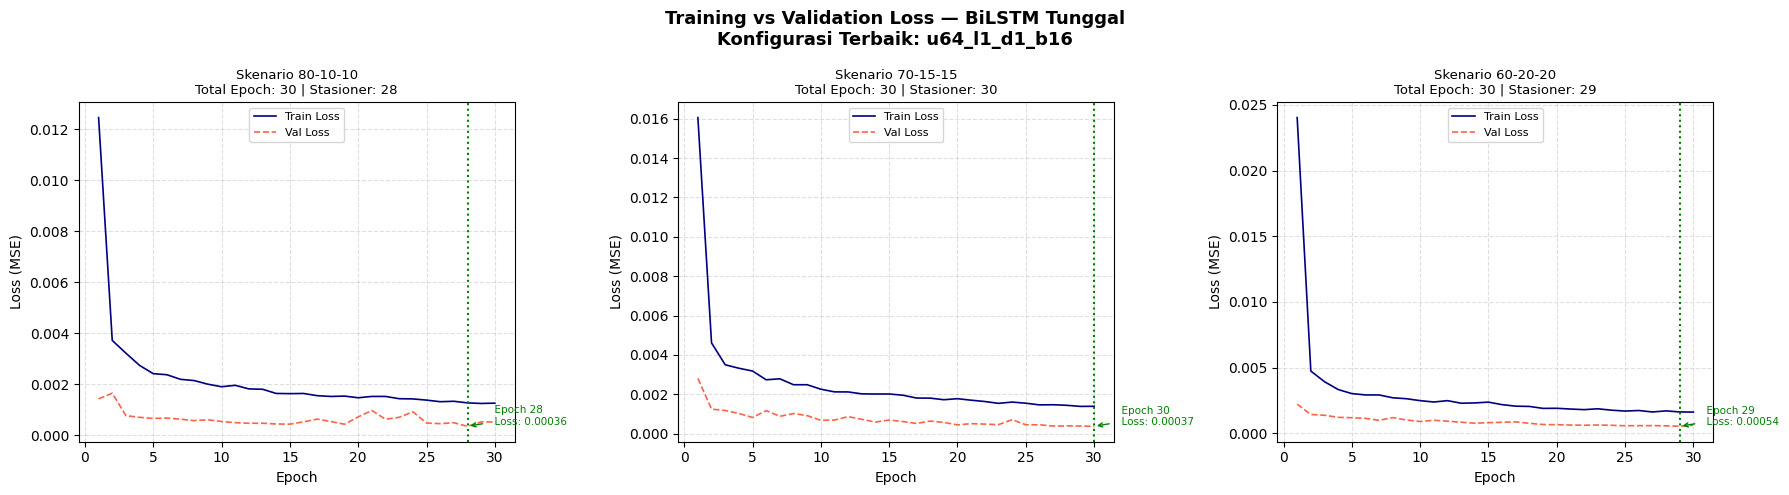

✅ Loss curve disimpan ke: 'loss_curve_BiLSTM.png'


In [9]:
# ============================================================
# VISUALISASI 1 — LOSS CURVE
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(
    'Training vs Validation Loss — BiLSTM Tunggal\n'
    f'Konfigurasi Terbaik: {konfigurasi_terbaik["nama"]}',
    fontsize=13, fontweight='bold'
)

for col_idx, nama_skenario in enumerate(skenario_final):
    key = f"{konfigurasi_terbaik['nama']}_{nama_skenario}"
    ax  = axes[col_idx]
    h   = history_final[key]

    total_epoch   = len(h['loss'])
    val_loss_arr  = np.array(h['val_loss'])
    best_epoch    = int(np.argmin(val_loss_arr)) + 1
    best_val_loss = val_loss_arr[best_epoch - 1]

    ax.plot(range(1, total_epoch + 1), h['loss'],
            label='Train Loss', color='navy', linewidth=1.2)
    ax.plot(range(1, total_epoch + 1), h['val_loss'],
            label='Val Loss', color='tomato',
            linewidth=1.2, linestyle='--')

    ax.axvline(x=best_epoch, color='green', linestyle=':', linewidth=1.5)
    ax.annotate(
        f'  Epoch {best_epoch}\n  Loss: {best_val_loss:.5f}',
        xy=(best_epoch, best_val_loss),
        xytext=(best_epoch + total_epoch * 0.05, best_val_loss * 1.15),
        fontsize=7.5, color='green',
        arrowprops=dict(arrowstyle='->', color='green', lw=1)
    )

    ax.set_title(
        f'Skenario {nama_skenario}\n'
        f'Total Epoch: {total_epoch} | Stasioner: {best_epoch}',
        fontsize=9.5
    )
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss (MSE)')
    ax.legend(fontsize=8)
    ax.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig('loss_curve_BiLSTM.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Loss curve disimpan ke: 'loss_curve_BiLSTM.png'")

## CELL 10 — Perbandingan Metrik Evaluasi (Bar Chart)

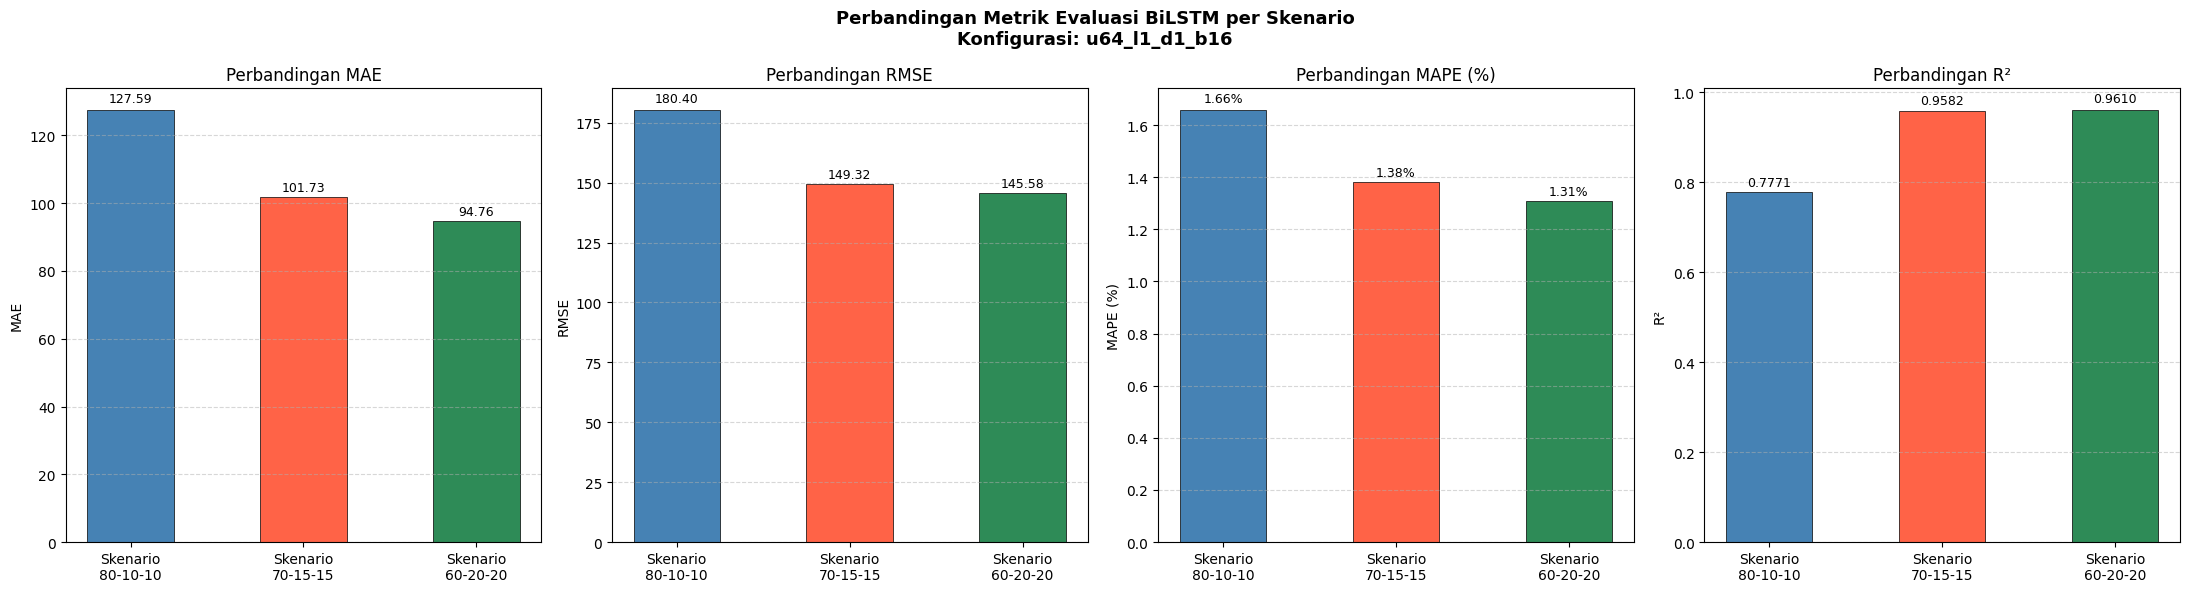


🏆 Performa terbaik BiLSTM:
   Skenario      : 60-20-20
   MAE           : 94.76
   RMSE          : 145.58
   MAPE          : 1.3076%
   R²            : 0.9610
   Waktu Training: 73.12 detik


In [10]:
fig, axes = plt.subplots(1, 4, figsize=(22, 6))
fig.suptitle(
    f'Perbandingan Metrik Evaluasi BiLSTM per Skenario\n'
    f'Konfigurasi: {konfigurasi_terbaik["nama"]}',
    fontsize=13, fontweight='bold'
)

metrik_list  = ['MAE', 'RMSE', 'MAPE (%)', 'R2']
metrik_label = ['MAE', 'RMSE', 'MAPE (%)', 'R²']
bar_colors   = ['steelblue', 'tomato', 'seagreen']

for i, (metrik, label) in enumerate(zip(metrik_list, metrik_label)):
    ax   = axes[i]
    vals = df_final_hasil[metrik].values

    bars = ax.bar(
        [f'Skenario\n{s}' for s in skenario_final],
        vals, color=bar_colors,
        edgecolor='black', linewidth=0.5, width=0.5
    )

    for bar, val in zip(bars, vals):
        if metrik == 'MAPE (%)':
            txt = f'{val:.2f}%'
        elif metrik == 'R2':
            txt = f'{val:.4f}'
        else:
            txt = f'{val:.2f}'
        ax.text(bar.get_x() + bar.get_width()/2,
                val + 0.01 * val,
                txt, ha='center', va='bottom', fontsize=9)

    ax.set_ylabel(label)
    ax.set_title(f'Perbandingan {label}')
    ax.grid(True, axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('evaluasi_perbandingan_BiLSTM.png', dpi=150, bbox_inches='tight')
plt.show()

best_row = df_final_hasil.loc[df_final_hasil['MAPE (%)'].idxmin()]
print(f"\n🏆 Performa terbaik BiLSTM:")
print(f"   Skenario      : {best_row['Skenario']}")
print(f"   MAE           : {best_row['MAE']:.2f}")
print(f"   RMSE          : {best_row['RMSE']:.2f}")
print(f"   MAPE          : {best_row['MAPE (%)']}%")
print(f"   R²            : {best_row['R2']:.4f}")
print(f"   Waktu Training: {best_row['Waktu (detik)']} detik")

## CELL 11 — Visualisasi Prediksi vs Aktual (1 Grafik Terbaik)

**Revisi:** Hanya menampilkan 1 grafik dari model dengan MAPE terkecil,
bukan semua 6 kombinasi.


Model terbaik: u64_l1_d1_b16_60-20-20
MAE: 94.76 | RMSE: 145.58 | MAPE: 1.3076% | R²: 0.9610


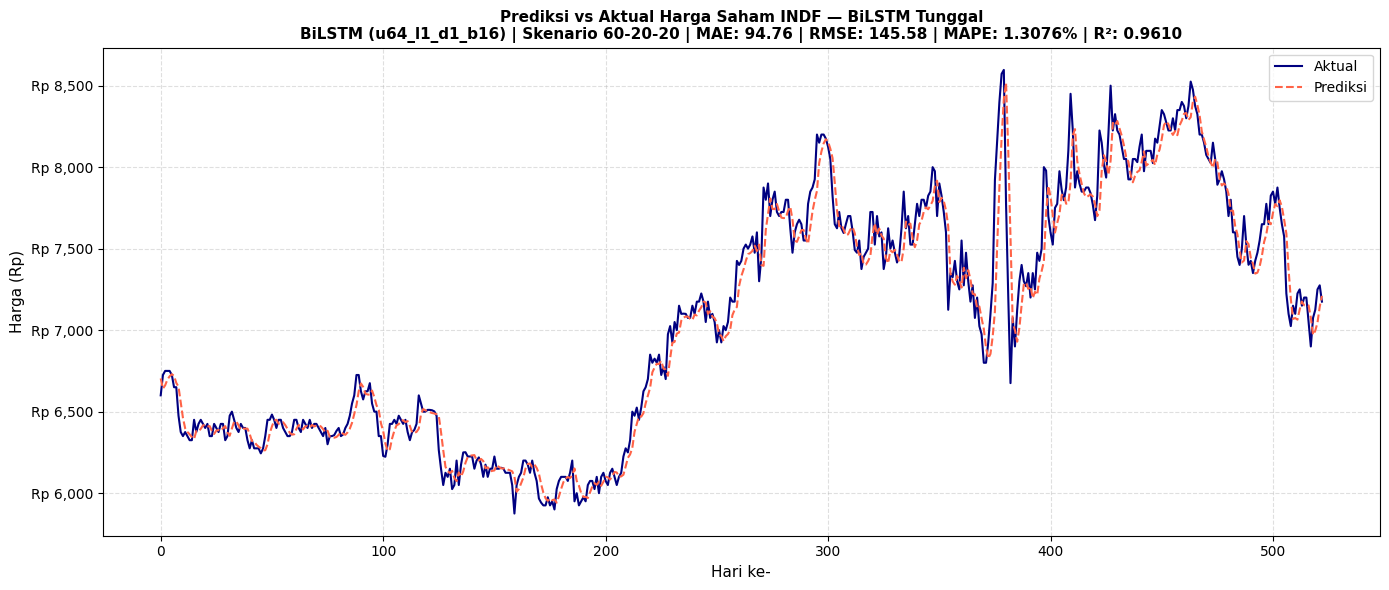

✅ Grafik prediksi vs aktual disimpan ke: 'prediksi_vs_aktual_terbaik_BiLSTM.png'


In [11]:
best_idx      = df_final_hasil['MAPE (%)'].idxmin()
best_row      = df_final_hasil.loc[best_idx]
best_key      = f"{best_row['Konfigurasi']}_{best_row['Skenario']}"
best_skenario = best_row['Skenario']
best_label    = f"BiLSTM ({best_row['Konfigurasi']})"
best_mape     = best_row['MAPE (%)']
best_mae      = best_row['MAE']
best_rmse     = best_row['RMSE']
best_r2       = best_row['R2']

print(f"\nModel terbaik: {best_key}")
print(f"MAE: {best_mae:.2f} | RMSE: {best_rmse:.2f} | MAPE: {best_mape:.4f}% | R²: {best_r2:.4f}")

data = datasets[best_skenario]

y_pred_scaled = model_final[best_key].predict(data['X_test'], verbose=0)
y_true = data['scaler'].inverse_transform(data['y_test'].reshape(-1, 1)).flatten()
y_pred = data['scaler'].inverse_transform(y_pred_scaled).flatten()

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(y_true, label='Aktual', color='navy', linewidth=1.5)
ax.plot(y_pred, label='Prediksi', color='tomato', linewidth=1.5, linestyle='--')
ax.set_title(
    f'Prediksi vs Aktual Harga Saham INDF — BiLSTM Tunggal\n'
    f'{best_label} | Skenario {best_skenario} | '
    f'MAE: {best_mae:.2f} | RMSE: {best_rmse:.2f} | MAPE: {best_mape:.4f}% | R²: {best_r2:.4f}',
    fontsize=11, fontweight='bold'
)
ax.set_xlabel('Hari ke-', fontsize=11)
ax.set_ylabel('Harga (Rp)', fontsize=11)
ax.legend(fontsize=10)
ax.grid(True, linestyle='--', alpha=0.4)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'Rp {int(x):,}'))
plt.tight_layout()
plt.savefig('prediksi_vs_aktual_terbaik_BiLSTM.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Grafik prediksi vs aktual disimpan ke: 'prediksi_vs_aktual_terbaik_BiLSTM.png'")

## CELL 13 — Prediksi 1 Hari & 30 Hari ke Depan

Kedua prediksi dijalankan dalam 1 cell menggunakan strategi **recursive forecasting**:
- Loop 30 iterasi, iterasi pertama = prediksi 1 hari (23 Oktober 2025)
- Setiap hasil prediksi dianggap aktual dan dimasukkan ke window berikutnya
- Output: prediksi 1 hari + tabel & grafik prediksi 30 hari



  PREDIKSI HARGA SAHAM INDF — 1 HARI KE DEPAN
  Model            : u64_l1_d1_b16_60-20-20
  Data terakhir    : 22 October 2025 | Harga: Rp 7,175
  Tanggal prediksi : 23 October 2025
  Prediksi Harga   : Rp 7,193.83
  Selisih          : Rp 18.83 (naik)

  PREDIKSI HARGA SAHAM INDF — 30 HARI KE DEPAN
  Mulai   : 23 October 2025
  Selesai : 03 December 2025
         Tanggal  Prediksi (Rp)
 23 October 2025    7193.830078
 24 October 2025    7183.500000
 27 October 2025    7169.379883
 28 October 2025    7154.750000
 29 October 2025    7137.470215
 30 October 2025    7121.830078
 31 October 2025    7099.640137
03 November 2025    7077.459961
04 November 2025    7054.379883
05 November 2025    7027.549805
06 November 2025    7004.100098
07 November 2025    6981.799805
10 November 2025    6962.790039
11 November 2025    6951.399902
12 November 2025    6938.930176
13 November 2025    6926.080078
14 November 2025    6910.100098
17 November 2025    6895.759766
18 November 2025    6878.209961
19

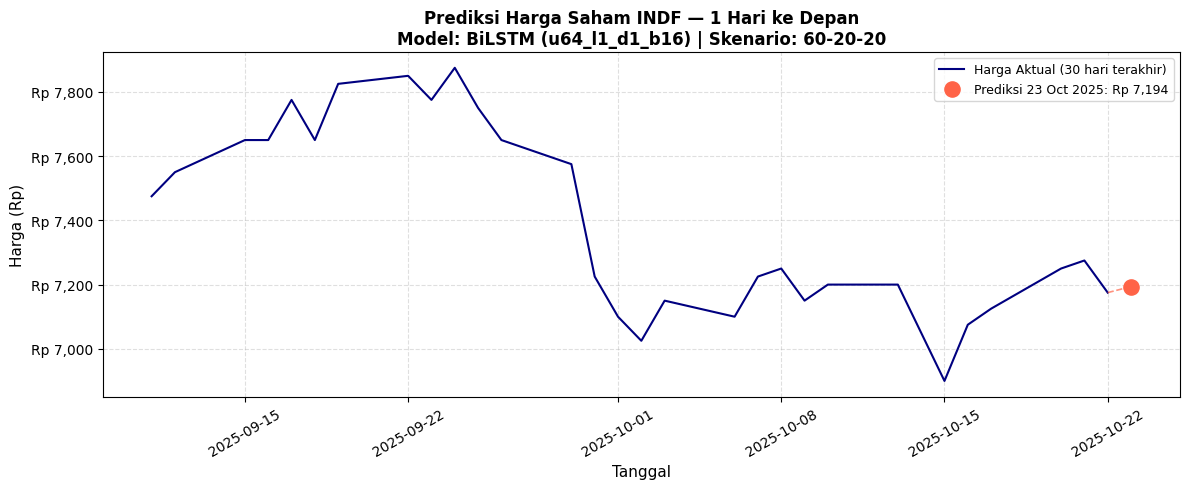

✅ Grafik prediksi 1 hari disimpan ke: 'prediksi_1hari_BiLSTM.png'


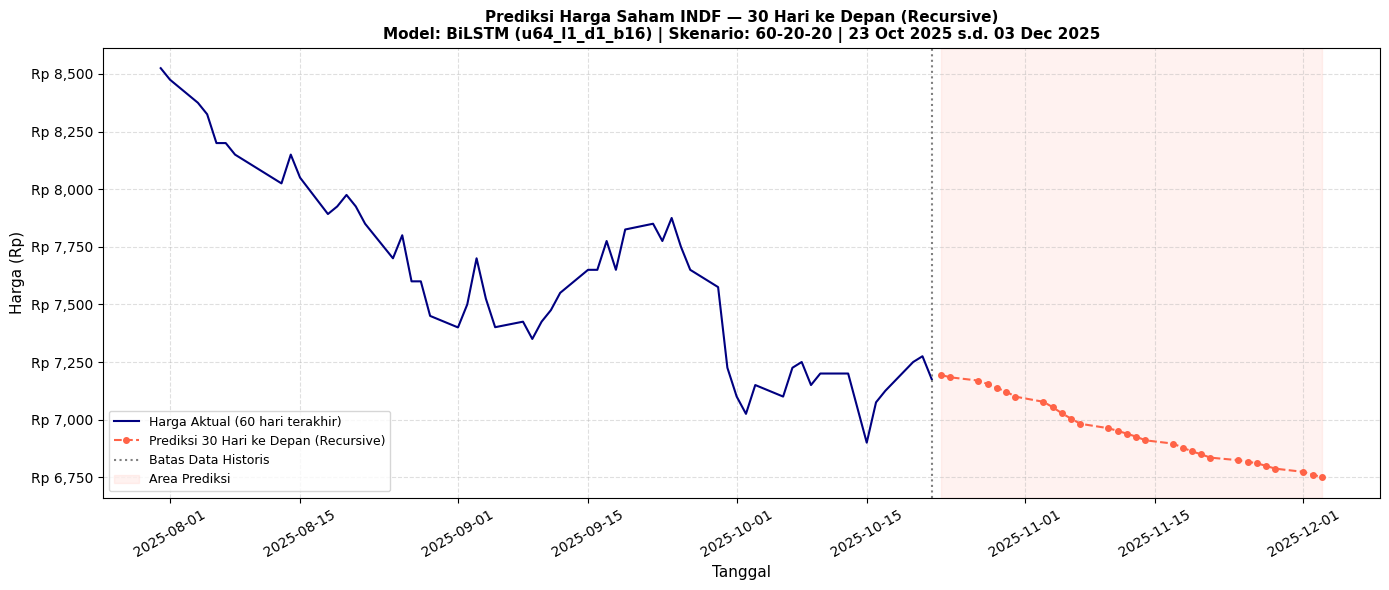

✅ Grafik prediksi 30 hari disimpan ke: 'prediksi_30hari_BiLSTM.png'


In [12]:
model_terbaik      = model_final[best_key]
scaler_terbaik     = datasets[best_skenario]['scaler']
data_close_full    = df[['Close']].values
last_window_raw    = data_close_full[-WINDOW_SIZE:]
last_window_scaled = scaler_terbaik.transform(last_window_raw)
tanggal_terakhir   = df.index[-1]

DAYS_AHEAD     = 30
current_window = last_window_scaled.copy()
prediksi_list  = []

for hari in range(DAYS_AHEAD):
    X_input = current_window.reshape(1, WINDOW_SIZE, 1)
    pred    = model_terbaik.predict(X_input, verbose=0)[0][0]
    prediksi_list.append(pred)
    new_point      = np.array([[pred]])
    current_window = np.concatenate([current_window[1:], new_point], axis=0)

prediksi_scaled_arr = np.array(prediksi_list).reshape(-1, 1)
prediksi_rupiah_arr = scaler_terbaik.inverse_transform(prediksi_scaled_arr).flatten()

tanggal_awal = tanggal_terakhir + pd.offsets.BDay(1)
tanggal_pred = pd.date_range(start=tanggal_awal, periods=DAYS_AHEAD, freq='B')

# Output 1 hari
pred_1hari     = prediksi_rupiah_arr[0]
tanggal_1hari  = tanggal_pred[0]
harga_terakhir = data_close_full[-1][0]
selisih        = pred_1hari - harga_terakhir
arah           = "naik" if selisih >= 0 else "turun"

print("\n" + "=" * 55)
print("  PREDIKSI HARGA SAHAM INDF — 1 HARI KE DEPAN")
print("=" * 55)
print(f"  Model            : {best_key}")
print(f"  Data terakhir    : {tanggal_terakhir.strftime('%d %B %Y')} "
      f"| Harga: Rp {harga_terakhir:,.0f}")
print(f"  Tanggal prediksi : {tanggal_1hari.strftime('%d %B %Y')}")
print(f"  Prediksi Harga   : Rp {pred_1hari:,.2f}")
print(f"  Selisih          : Rp {abs(selisih):,.2f} ({arah})")
print("=" * 55)

# Output 30 hari
df_prediksi_30 = pd.DataFrame({
    'Tanggal'       : tanggal_pred.strftime('%d %B %Y'),
    'Prediksi (Rp)' : prediksi_rupiah_arr.round(2)
})
print("\n" + "=" * 55)
print("  PREDIKSI HARGA SAHAM INDF — 30 HARI KE DEPAN")
print("=" * 55)
print(f"  Mulai   : {tanggal_pred[0].strftime('%d %B %Y')}")
print(f"  Selesai : {tanggal_pred[-1].strftime('%d %B %Y')}")
print("=" * 55)
print(df_prediksi_30.to_string(index=False))
df_prediksi_30.to_csv('prediksi_30hari_BiLSTM.csv', index=False)
print("\n✅ Hasil disimpan ke: 'prediksi_30hari_BiLSTM.csv'")

# Grafik 1 hari
fig, ax = plt.subplots(figsize=(12, 5))
tanggal_hist = df.index[-WINDOW_SIZE:]
harga_hist   = data_close_full[-WINDOW_SIZE:].flatten()
ax.plot(tanggal_hist, harga_hist, label='Harga Aktual (30 hari terakhir)',
        color='navy', linewidth=1.5)
label_1hari = f"Prediksi {tanggal_1hari.strftime('%d %b %Y')}: Rp {pred_1hari:,.0f}"
ax.scatter([tanggal_1hari], [pred_1hari], color='tomato', s=120, zorder=5, label=label_1hari)
ax.plot([tanggal_hist[-1], tanggal_1hari], [harga_hist[-1], pred_1hari],
        color='tomato', linestyle='--', linewidth=1.2, alpha=0.7)
ax.set_title(
    f'Prediksi Harga Saham INDF — 1 Hari ke Depan\n'
    f'Model: {best_label} | Skenario: {best_skenario}',
    fontsize=12, fontweight='bold'
)
ax.set_xlabel('Tanggal', fontsize=11)
ax.set_ylabel('Harga (Rp)', fontsize=11)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'Rp {int(x):,}'))
ax.legend(fontsize=9)
ax.grid(True, linestyle='--', alpha=0.4)
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('prediksi_1hari_BiLSTM.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Grafik prediksi 1 hari disimpan ke: 'prediksi_1hari_BiLSTM.png'")

# Grafik 30 hari
LOOKBACK_VIS     = 60
tanggal_hist_vis = df.index[-LOOKBACK_VIS:]
harga_hist_vis   = data_close_full[-LOOKBACK_VIS:].flatten()
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(tanggal_hist_vis, harga_hist_vis, label='Harga Aktual (60 hari terakhir)',
        color='navy', linewidth=1.5)
ax.plot(tanggal_pred, prediksi_rupiah_arr,
        label='Prediksi 30 Hari ke Depan (Recursive)',
        color='tomato', linewidth=1.5, linestyle='--', marker='o', markersize=4)
ax.axvline(x=tanggal_terakhir, color='gray', linestyle=':', linewidth=1.5,
           label='Batas Data Historis')
ax.axvspan(tanggal_pred[0], tanggal_pred[-1], alpha=0.08, color='tomato',
           label='Area Prediksi')
tgl_mulai   = tanggal_pred[0].strftime('%d %b %Y')
tgl_selesai = tanggal_pred[-1].strftime('%d %b %Y')
ax.set_title(
    f'Prediksi Harga Saham INDF — 30 Hari ke Depan (Recursive)\n'
    f'Model: {best_label} | Skenario: {best_skenario} | '
    f'{tgl_mulai} s.d. {tgl_selesai}',
    fontsize=11, fontweight='bold'
)
ax.set_xlabel('Tanggal', fontsize=11)
ax.set_ylabel('Harga (Rp)', fontsize=11)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'Rp {int(x):,}'))
ax.legend(fontsize=9)
ax.grid(True, linestyle='--', alpha=0.4)
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('prediksi_30hari_BiLSTM.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Grafik prediksi 30 hari disimpan ke: 'prediksi_30hari_BiLSTM.png'")